# RDF Generator Performance Comparison

This notebook compares the throughput performance of different RDF synthetic data generators across multiple runs.

In [9]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

## Load Performance Data from All Runs

This function scans all generator folders and collects benchmark data from each run.

In [ ]:
def load_benchmark_data(datasets_dir="1-Datasets"):
    """
    Load benchmark data from all generators and all runs.
    Returns a DataFrame with columns: Generator, Run, Throughput, Triples, ExecutionTime
    """
    data = []
    
    datasets_path = Path(datasets_dir)
    
    if not datasets_path.exists():
        print(f"Dataset directory not found: {datasets_dir}")
        return pd.DataFrame()
    
    # Iterate through each generator folder
    for generator_folder in datasets_path.iterdir():
        if not generator_folder.is_dir() or generator_folder.name.startswith('.'):
            continue
            
        generator_name = generator_folder.name
        
        # Iterate through each run folder
        for run_folder in generator_folder.iterdir():
            if not run_folder.is_dir() or not run_folder.name.startswith('run_'):
                continue
                
            run_number = int(run_folder.name.split('_')[1])
            
            # Load benchmark report
            benchmark_file = run_folder / 'benchmark_report.json'
            metadata_file = run_folder / 'metadata.json'
            
            if benchmark_file.exists():
                try:
                    with open(benchmark_file, 'r') as f:
                        benchmark = json.load(f)
                    
                    # Extract throughput and other metrics
                    throughput = None
                    triples = None
                    exec_time = None
                    
                    # Different generators have different JSON structures
                    # Throughput extraction
                    if 'performance_metrics' in benchmark:
                        throughput = benchmark['performance_metrics'].get('triples_per_second')
                    elif 'performance' in benchmark:
                        throughput = benchmark['performance'].get('triples_per_second')
                    elif 'throughput' in benchmark:
                        if isinstance(benchmark['throughput'], dict):
                            throughput = benchmark['throughput'].get('triples_per_second')
                        else:
                            throughput = benchmark['throughput']
                    elif 'generated_data' in benchmark and 'triples_per_second' in benchmark['generated_data']:
                        throughput = benchmark['generated_data']['triples_per_second']
                    elif 'triples_per_second' in benchmark:
                        throughput = benchmark['triples_per_second']
                    
                    # Triples count extraction
                    if 'generated_data' in benchmark:
                        if 'triples_total' in benchmark['generated_data']:
                            triples = benchmark['generated_data']['triples_total']
                        elif 'estimated_triples' in benchmark['generated_data']:
                            triples = benchmark['generated_data']['estimated_triples']
                        elif 'total_triples' in benchmark['generated_data']:
                            triples = benchmark['generated_data']['total_triples']
                    elif 'triples' in benchmark:
                        if isinstance(benchmark['triples'], dict):
                            triples = benchmark['triples'].get('total', benchmark['triples'].get('total_triples'))
                        else:
                            triples = benchmark['triples']
                    elif 'total_triples' in benchmark:
                        triples = benchmark['total_triples']
                    elif 'estimated_triples' in benchmark:
                        triples = benchmark['estimated_triples']
                    
                    # Special handling for GAIA - parse stdout for actual instance count
                    if 'results' in benchmark and 'instances_generated' in benchmark['results']:
                        instances = benchmark['results']['instances_generated']
                        # If instances_generated is 0 or None, try to parse stdout
                        if (instances is None or instances == 0) and 'stdout' in benchmark:
                            import re
                            # Look for pattern like "43000 instances has been generated"
                            match = re.search(r'(\d+)\s+instances\s+(?:has been generated|writted)', benchmark['stdout'])
                            if match:
                                instances = int(match.group(1))
                        
                        # Approximate triples as instances * 3 (each instance typically has ~3 triples)
                        if instances and instances > 0:
                            triples = instances * 3
                    
                    # Execution time extraction
                    if 'execution' in benchmark and 'time_seconds' in benchmark['execution']:
                        exec_time = benchmark['execution']['time_seconds']
                    elif 'results' in benchmark and 'execution_time_seconds' in benchmark['results']:
                        exec_time = benchmark['results']['execution_time_seconds']
                    elif 'execution_time' in benchmark:
                        if isinstance(benchmark['execution_time'], dict):
                            exec_time = benchmark['execution_time'].get('seconds', benchmark['execution_time'].get('time_seconds'))
                        else:
                            exec_time = benchmark['execution_time']
                    elif 'execution_time_seconds' in benchmark:
                        exec_time = benchmark['execution_time_seconds']
                    elif 'time_seconds' in benchmark:
                        exec_time = benchmark['time_seconds']
                    
                    # Calculate throughput if we have triples and exec_time but not throughput
                    if throughput is None and triples is not None and exec_time is not None and exec_time > 0:
                        throughput = triples / exec_time
                    
                    data.append({
                        'Generator': generator_name,
                        'Run': run_number,
                        'Throughput': throughput,
                        'Triples': triples,
                        'ExecutionTime': exec_time
                    })
                    
                except Exception as e:
                    print(f"Error loading {benchmark_file}: {e}")
    
    df = pd.DataFrame(data)
    return df

# Load the data
df_performance = load_benchmark_data()
print(f"Loaded {len(df_performance)} benchmark results")
display(df_performance)

Loaded 8 benchmark results


,Generator,Run,Throughput,Triples,ExecutionTime
0,RUDOFGENERATE,1,30904.831682,1466639.0,47.456625
1,BSBM,1,530265.470000,3564773.0,6.723000
2,PYGRAFT,1,1191.090000,4490.0,3.770000
3,LINKGEN,1,18197.740000,NaN,16.486000
4,RDFGRAPHGEN,1,1234.690000,3690.0,2.989000
5,GAIA,1,NaN,NaN,0.643738
6,LUBM,1,306817.420000,NaN,4.290245
7,RDFMUTATE,1,NaN,NaN,4.488000


## Calculate Statistics by Generator

Calculate mean, standard deviation, min, and max throughput for each generator across all runs.

In [11]:
# Calculate statistics grouped by generator
stats = df_performance.groupby('Generator')['Throughput'].agg([
    ('Mean', 'mean'),
    ('Std', 'std'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Count', 'count')
]).round(2)

print("\nThroughput Statistics by Generator (triples/second):")
display(stats)


Throughput Statistics by Generator (triples/second):


,Mean,Std,Min,Max,Count
Generator,,,,,
BSBM,530265.47,NaN,530265.47,530265.47,1
GAIA,NaN,NaN,NaN,NaN,0
LINKGEN,18197.74,NaN,18197.74,18197.74,1
LUBM,306817.42,NaN,306817.42,306817.42,1
PYGRAFT,1191.09,NaN,1191.09,1191.09,1
RDFGRAPHGEN,1234.69,NaN,1234.69,1234.69,1
RDFMUTATE,NaN,NaN,NaN,NaN,0
RUDOFGENERATE,30904.83,NaN,30904.83,30904.83,1


## Throughput Comparison with Error Bars

Bar chart showing average throughput with standard deviation as error bars (whiskers).

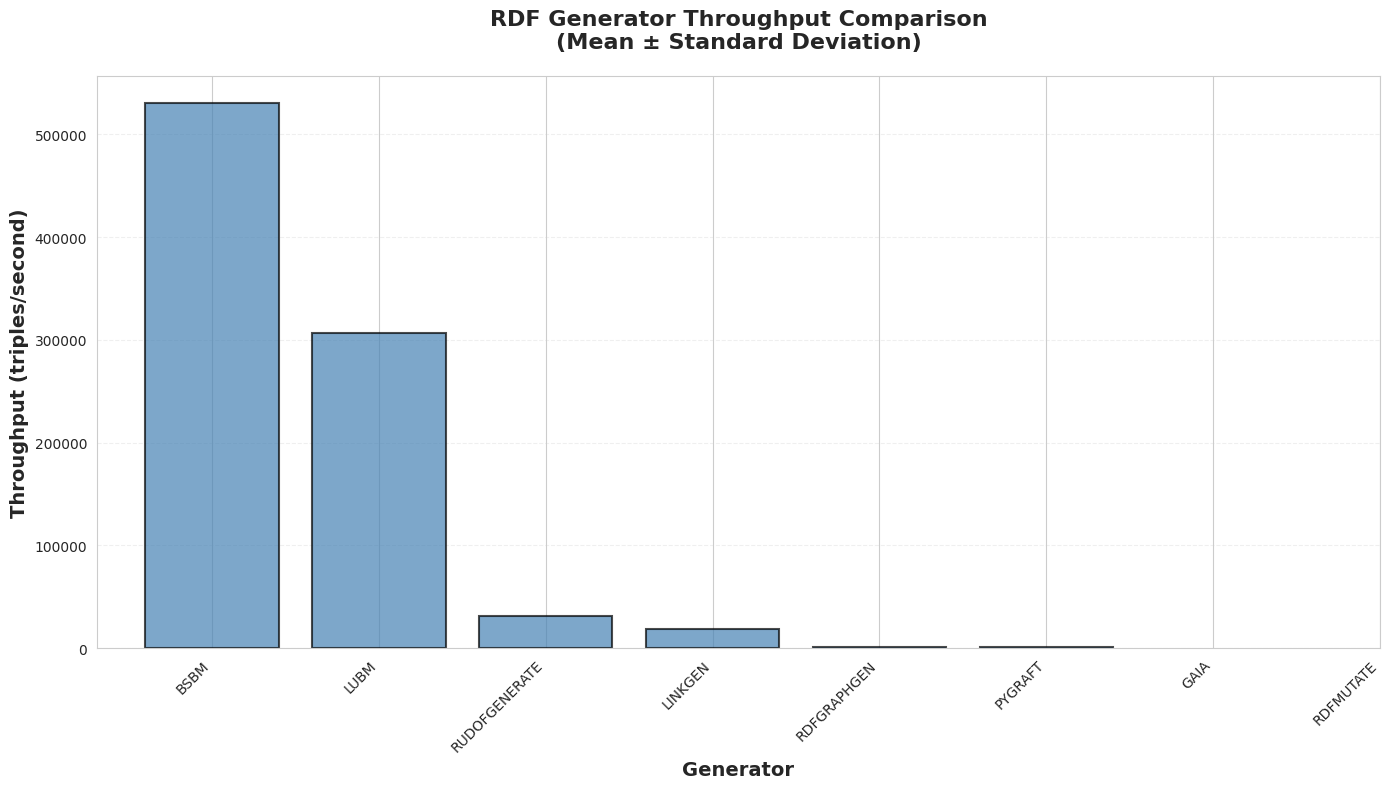

In [12]:
# Prepare data for plotting
plot_data = stats.reset_index()
plot_data = plot_data.sort_values('Mean', ascending=False)

# Create bar chart with error bars
fig, ax = plt.subplots(figsize=(14, 8))

x_pos = np.arange(len(plot_data))
bars = ax.bar(x_pos, plot_data['Mean'], 
               yerr=plot_data['Std'],
               alpha=0.7,
               capsize=10,
               color='steelblue',
               edgecolor='black',
               linewidth=1.5,
               error_kw={'linewidth': 2, 'ecolor': 'darkred'})

# Customize the plot
ax.set_xlabel('Generator', fontsize=14, fontweight='bold')
ax.set_ylabel('Throughput (triples/second)', fontsize=14, fontweight='bold')
ax.set_title('RDF Generator Throughput Comparison\n(Mean ± Standard Deviation)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(plot_data['Generator'], rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on top of bars
for i, (idx, row) in enumerate(plot_data.iterrows()):
    height = row['Mean']
    ax.text(i, height + row['Std'] + max(plot_data['Mean']) * 0.02,
            f"{height:,.0f}\n(n={int(row['Count'])})",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Box Plot - Distribution of Throughput Across Runs

Box plots show the distribution, median, and outliers for each generator.

/tmp/ipykernel_30486/3014603920.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_performance, x='Generator', y='Throughput',


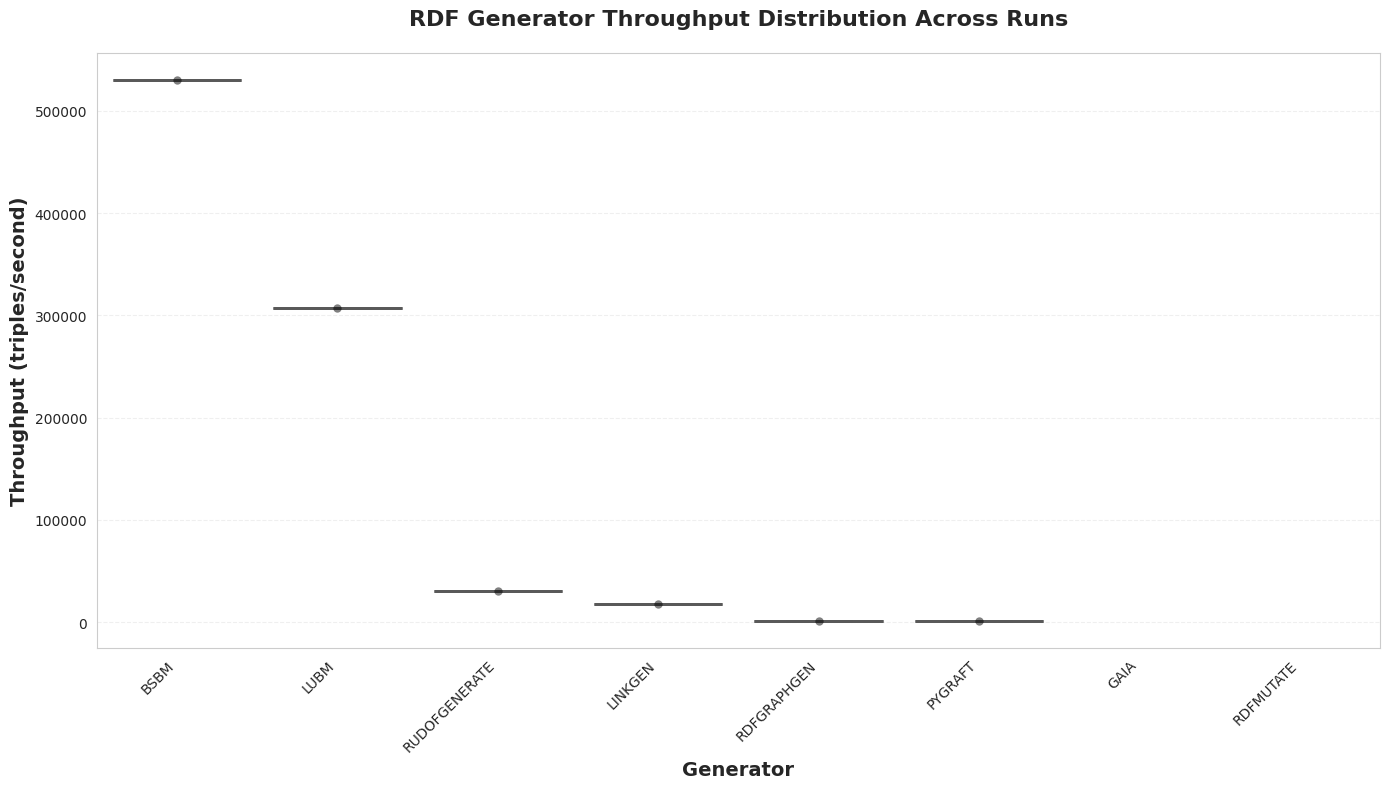

In [13]:
# Create box plot
fig, ax = plt.subplots(figsize=(14, 8))

# Sort generators by median throughput
generator_order = df_performance.groupby('Generator')['Throughput'].median().sort_values(ascending=False).index

sns.boxplot(data=df_performance, x='Generator', y='Throughput', 
            order=generator_order,
            palette='Set2',
            ax=ax,
            linewidth=2)

# Add individual points
sns.swarmplot(data=df_performance, x='Generator', y='Throughput',
              order=generator_order,
              color='black',
              alpha=0.5,
              size=6,
              ax=ax)

ax.set_xlabel('Generator', fontsize=14, fontweight='bold')
ax.set_ylabel('Throughput (triples/second)', fontsize=14, fontweight='bold')
ax.set_title('RDF Generator Throughput Distribution Across Runs', 
             fontsize=16, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45)
plt.setp(ax.get_xticklabels(), ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## Throughput Trends Across Runs

Line plot showing how throughput varies across different runs for each generator.

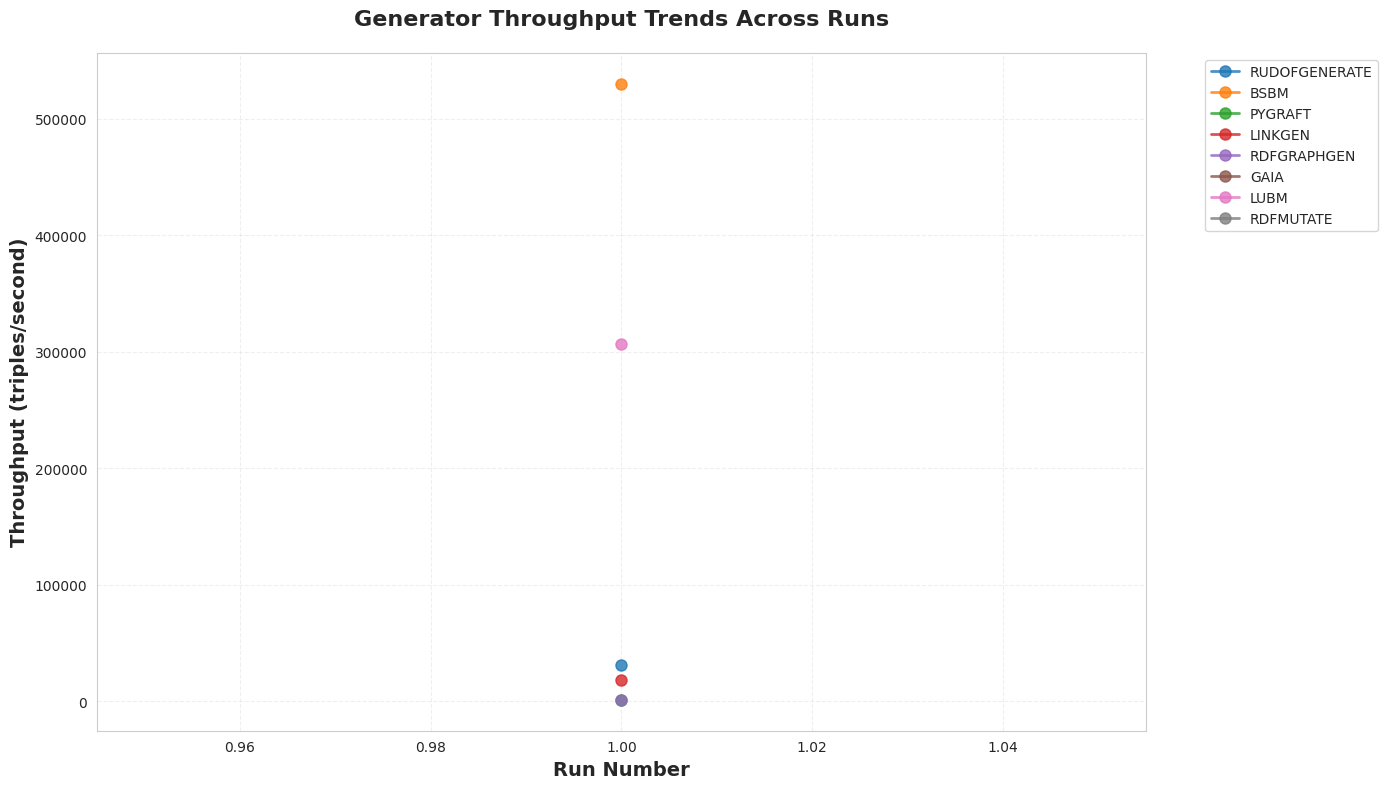

In [14]:
# Create line plot for trends
fig, ax = plt.subplots(figsize=(14, 8))

# Plot each generator
for generator in df_performance['Generator'].unique():
    gen_data = df_performance[df_performance['Generator'] == generator].sort_values('Run')
    ax.plot(gen_data['Run'], gen_data['Throughput'], 
            marker='o', markersize=8, linewidth=2, 
            label=generator, alpha=0.8)

ax.set_xlabel('Run Number', fontsize=14, fontweight='bold')
ax.set_ylabel('Throughput (triples/second)', fontsize=14, fontweight='bold')
ax.set_title('Generator Throughput Trends Across Runs', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## Execution Time Comparison

Compare execution times across generators with error bars.

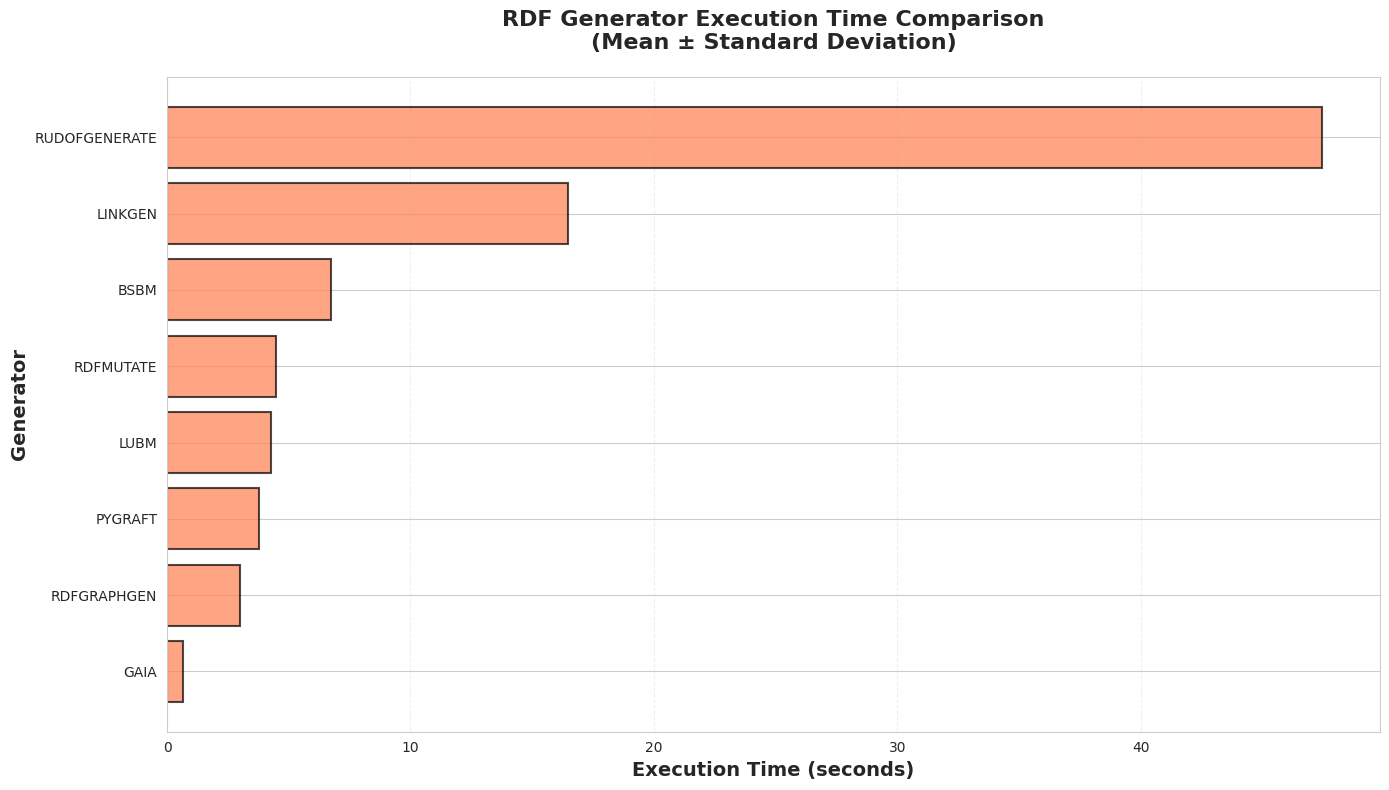

In [15]:
# Calculate execution time statistics
exec_stats = df_performance.groupby('Generator')['ExecutionTime'].agg([
    ('Mean', 'mean'),
    ('Std', 'std'),
    ('Count', 'count')
]).reset_index().sort_values('Mean', ascending=True)

# Create bar chart for execution time
fig, ax = plt.subplots(figsize=(14, 8))

x_pos = np.arange(len(exec_stats))
bars = ax.barh(x_pos, exec_stats['Mean'], 
                xerr=exec_stats['Std'],
                alpha=0.7,
                capsize=10,
                color='coral',
                edgecolor='black',
                linewidth=1.5,
                error_kw={'linewidth': 2, 'ecolor': 'darkred'})

ax.set_yticks(x_pos)
ax.set_yticklabels(exec_stats['Generator'])
ax.set_xlabel('Execution Time (seconds)', fontsize=14, fontweight='bold')
ax.set_ylabel('Generator', fontsize=14, fontweight='bold')
ax.set_title('RDF Generator Execution Time Comparison\n(Mean ± Standard Deviation)', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, (idx, row) in enumerate(exec_stats.iterrows()):
    width = row['Mean']
    ax.text(width + row['Std'] + max(exec_stats['Mean']) * 0.02, i,
            f"{width:.2f}s (n={int(row['Count'])})",
            ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Summary Table

Complete summary of all generators with key metrics.

In [16]:
# Create comprehensive summary
summary = df_performance.groupby('Generator').agg({
    'Throughput': ['mean', 'std', 'min', 'max'],
    'Triples': ['mean', 'std'],
    'ExecutionTime': ['mean', 'std'],
    'Run': 'count'
}).round(2)

summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary = summary.rename(columns={'Run_count': 'Total_Runs'})
summary = summary.sort_values('Throughput_mean', ascending=False)

print("\n" + "="*80)
print("COMPREHENSIVE GENERATOR PERFORMANCE SUMMARY")
print("="*80)
display(summary)

# Save to CSV
summary.to_csv('generator_performance_summary.csv')
print("\n💾 Summary saved to 'generator_performance_summary.csv'")


COMPREHENSIVE GENERATOR PERFORMANCE SUMMARY


,Throughput_mean,Throughput_std,Throughput_min,Throughput_max,Triples_mean,Triples_std,ExecutionTime_mean,ExecutionTime_std,Total_Runs
Generator,,,,,,,,,
BSBM,530265.47,NaN,530265.47,530265.47,3564773.0,NaN,6.72,NaN,1
LUBM,306817.42,NaN,306817.42,306817.42,NaN,NaN,4.29,NaN,1
RUDOFGENERATE,30904.83,NaN,30904.83,30904.83,1466639.0,NaN,47.46,NaN,1
LINKGEN,18197.74,NaN,18197.74,18197.74,NaN,NaN,16.49,NaN,1
RDFGRAPHGEN,1234.69,NaN,1234.69,1234.69,3690.0,NaN,2.99,NaN,1
PYGRAFT,1191.09,NaN,1191.09,1191.09,4490.0,NaN,3.77,NaN,1
GAIA,NaN,NaN,NaN,NaN,NaN,NaN,0.64,NaN,1
RDFMUTATE,NaN,NaN,NaN,NaN,NaN,NaN,4.49,NaN,1



💾 Summary saved to 'generator_performance_summary.csv'
